<table style="border:none;border-collapse:collapse;margin:0 0 8px;width:100%;">
<tr style="border:none;">
  <td style="border:none;padding:0;vertical-align:middle;">
    <div style="font-family:ui-monospace,'SF Mono','JetBrains Mono',Menlo,monospace;font-size:10.5px;letter-spacing:.2em;text-transform:uppercase;margin:0 0 7px;">Companion notebook</div>
    <div style="font-family:Georgia,'Iowan Old Style',serif;font-size:18px;color:#1A1416;line-height:1.25;margin:0 0 7px;">
      <a href="https://www.manning.com/books/build-ai-drug-discovery-pipelines" style="color:#1A1416;text-decoration:none;border-bottom:1px solid #A20025;padding-bottom:1px;">Build AI Drug Discovery Pipelines</a>
    </div>
    <div style="font-family:ui-monospace,'SF Mono','JetBrains Mono',Menlo,monospace;font-size:12px;color:#6B6461;line-height:1.7;">
      Noah Flynn&nbsp;&middot;&nbsp;Manning Publications<br>
      Code&nbsp;&middot;&nbsp;<a href="https://github.com/nrflynn2/ml-drug-discovery" style="color:#A20025;text-decoration:none;">github.com/nrflynn2/ml-drug-discovery</a>
    </div>
  </td>
  <td style="border:none;padding:0 0 0 22px;vertical-align:middle;width:104px;text-align:right;">
    <a href="https://www.manning.com/books/build-ai-drug-discovery-pipelines">
      <img src="https://raw.githubusercontent.com/nrflynn2/ml-drug-discovery/main/assets/cover-sm.png" width="88" alt="Build AI Drug Discovery Pipelines cover" style="border:1px solid #E7E2DF;border-radius:3px;display:inline-block;">
    </a>
  </td>
</tr>
</table>
<hr style="border:0;border-top:1px solid #A20025;opacity:.55;margin:0 0 22px;">

# **Chapter 1: The Drug Discovery Process**

---

<em style="color:#6B6461;font-size:14.5px;">Runnable code for Chapter 1; read alongside the book.</em>

<a href="https://colab.research.google.com/github/nrflynn2/ml-drug-discovery/blob/main/CH01_FLYNN_ML4DD.ipynb" target="_blank"><img src="https://img.shields.io/badge/Open%20in-Colab-A20025?logo=googlecolab&logoColor=white" alt="Open in Colab" style="height:20px;vertical-align:middle;"></a>

<strong style="font-family:ui-monospace,'SF Mono','JetBrains Mono',Menlo,monospace;font-size:11px;letter-spacing:.16em;text-transform:uppercase;
">Objectives</strong>
<ol style="margin:8px 0 0;padding-left:22px;font-size:15.5px;">
<li style="margin:6px 0;">Represent molecules computationally by turning SMILES strings into RDKit objects</li>
<li style="margin:6px 0;">Generate ECFP6 fingerprints for FDA-approved drugs grouped by USAN stem</li>
<li style="margin:6px 0;">Explore the chemical space of those drugs with PCA, using no labels</li>
<li style="margin:6px 0;">Train a logistic-regression classifier to separate a drug class from principal components</li>
<li style="margin:6px 0;">Chart Eroom's Law, the R&amp;D productivity decline that motivates the book</li>
</ol>

---

## **Table of Contents**

---

## **Environment Setup**

<div style="font-size:14px;margin:0 0 6px;">
<div style="display:flex;gap:14px;padding:9px 0;"><strong style="font-family:ui-monospace,'SF Mono','JetBrains Mono',Menlo,monospace;font-size:11px;letter-spacing:.06em;text-transform:uppercase;color:#A20025;min-width:96px;">Local&#8195;&#8195;</strong><span>Install <a href="https://docs.astral.sh/uv/" style="color:#A20025;">uv</a>, then run <code>uv sync</code> from the repo root (Python 3.12) and launch with <code>uv run jupyter lab</code>.</span></div>
<div style="display:flex;gap:14px;padding:9px 0;"><strong style="font-family:ui-monospace,'SF Mono','JetBrains Mono',Menlo,monospace;font-size:11px;letter-spacing:.06em;text-transform:uppercase;color:#A20025;min-width:96px;">Colab&#8195;&#8195;</strong><span>Follow instructions on Colab notebook pinned above to install and setup environment, then restart the runtime.</span></div>
</div>

In [1]:
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("load_ext", "autoreload")
    ipython.run_line_magic("autoreload", "2")

In [2]:
import sys
import os
from pathlib import Path


# Set up directories
ROOT = str(Path.cwd().resolve().parent)
sys.path.append(ROOT)
os.chdir(ROOT)

CHAPTER = "ch01"
os.makedirs(f"{ROOT}/artifacts/{CHAPTER}", exist_ok=True)
os.makedirs(f"{ROOT}/data/{CHAPTER}", exist_ok=True)
os.makedirs(f"{ROOT}/figures/{CHAPTER}", exist_ok=True)
os.makedirs(f"{ROOT}/data/{CHAPTER}/fda_approved_drugs", exist_ok=True)

from aiddp.utils import fetch

# Fetch drug dataset
dataset_base_url = "https://raw.githubusercontent.com/nrflynn2/ml-drug-discovery/main/data/ch01/fda_approved_drugs"
drug_li = ["-caine", "-cillin", "-conazole", "-olol", "-oxacin", "-pine", "-terol", "-tinib", "-vir", "-sulfa"]
for drug in drug_li:
    fetch(f"{dataset_base_url}/{drug}.csv", f"{ROOT}/data/{CHAPTER}/fda_approved_drugs/{drug}.csv")

# fetch supplementary Eroom's law data
fetch("https://raw.githubusercontent.com/nrflynn2/ml-drug-discovery/main/data/ch01/eroom_law.csv", f"{ROOT}/data/{CHAPTER}/eroom_law.csv");

Now let's import all the packages we'll need for this chapter.

In [3]:
# Core data science packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chemical informatics packages
from rdkit import Chem
from rdkit.Chem import (
    AllChem,
    Descriptors,
    Draw, 
    PandasTools,
)
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

# Machine learning packages
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Book helper utilities (see utils.py in the repo root)
from aiddp.utils import check_env, set_seed, preview_df

# Define any constants
CHAPTER = "ch01"

# Reproducibility: seed Python, NumPy (and torch/CUDA if present) in one call.
SEED = set_seed(42)

# Print the runtime + key package versions so the notebook's results are
# self-documenting across local, WSL2, and Colab environments.
check_env(["numpy", "pandas", "matplotlib", "seaborn", "sklearn", "rdkit"])

import warnings
warnings.filterwarnings("ignore")

Python 3.12.13 (Linux)
  numpy            2.2.6
  pandas           2.3.3
  matplotlib       3.11.1
  seaborn          0.13.2
  sklearn          1.9.0
  rdkit            2025.09.6


In [4]:
from aiddp.utils import setup_visualization_style
from aiddp.utils import setup_rdkit_drawing

# Matplotlib and Seaborn setup for consistent visualizations
setup_visualization_style()
%matplotlib inline

# RDKit drawing setup
rdkit_drawing_options = setup_rdkit_drawing()

---

## **1.1 Deep Learning's Value Proposition**

---

## **1.2 What is Machine Learning? What is a Molecule?**

### **1.2.3 An Example Application with USAN Stems & RDKit**

This section demonstrates how we can represent molecules computationally and apply machine learning techniques to them. We'll explore:
 
1. How to use RDKit to handle molecular structures
2. How to visualize molecules
3. How to apply basic ML techniques to chemical data

#### **RDKIT: OPEN-SOURCE CHEMINFORMATICS SOFTWARE**

[RDKit](https://www.rdkit.org/) is an open-source cheminformatics toolkit that allows us to:
- Read and write various chemical file formats
- Generate 2D and 3D representations of molecules
- Calculate molecular descriptors and fingerprints
- Perform substructure searching and other operations
 
Let's start with a simple example using the caffeine molecule:

In [13]:
def create_molecule_from_smiles(smiles):
    """
    Convert a SMILES string to an RDKit molecule object.
    
    Parameters:
    -----------
    smiles : str
        SMILES representation of a molecule
        
    Returns:
    --------
    rdkit.Chem.rdchem.Mol
        RDKit molecule object, or None if parsing fails
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Warning: Could not parse SMILES string: {smiles}")
    return mol

def display_molecule_properties(mol):
    """
    Display basic properties of an RDKit molecule object.
    
    Parameters:
    -----------
    mol : rdkit.Chem.rdchem.Mol
        RDKit molecule object
    """
    if mol is None:
        print("No valid molecule to display")
        return
    
    print(f"Chemical Formula: {Chem.rdMolDescriptors.CalcMolFormula(mol)}")
    print(f"Number of atoms: {mol.GetNumAtoms()}")
    print(f"Number of bonds: {mol.GetNumBonds()}")
    print(f"Number of rings: {Chem.rdMolDescriptors.CalcNumRings(mol)}")
    
    # Calculate basic molecular properties
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    
    print(f"Molecular Weight: {mw:.2f}")
    print(f"LogP: {logp:.2f}")
    print(f"Topological Polar Surface Area: {tpsa:.2f}")

>**A short Note on molecular descriptors:**
>* Topological Polar Surface Area (TPSA) is a computationally efficient, 2D descriptor designed to estimate the sum of surfaces over all polar atoms in a molecule—primarily oxygen, nitrogen, sulfur, and phosphorus, along with their attached hydrogen atoms.
>* The octanol-water partition coefficient ($\log P$) is the foundational biophysical descriptor used in drug discovery to quantify molecular lipophilicity. It reflects the thermodynamic equilibrium ratio of a non-ionized compound’s concentrations between an organic phase ($n$-octanol) and an aqueous phase ($H_2O$ or buffer). Because $n$-octanol contains both a hydrophobic hydrocarbon chain and a polar hydroxyl group, it mimics the amphiphilic lipid bilayer environment of biological membranes, making $\log P$ a direct proxy for passive membrane transport and non-specific lipid binding.
> $$logP = log_{10}{(\frac{[solute]_{octanol}^{neutral}}{[solute]_{water}^{neutral}})}$$


Let's examine caffeine as our first example molecule.

Chemical Formula: C8H10N4O2
Number of atoms: 14
Number of bonds: 15
Number of rings: 2
Molecular Weight: 194.19
LogP: -1.03
Topological Polar Surface Area: 61.82


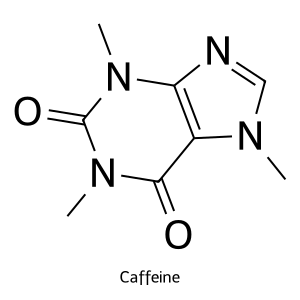

In [14]:
# Takeaway: this is the core RDKit workflow reused throughout the book --
# turn a SMILES string into a Mol object, read off its properties, and draw it.
# SMILES representation of caffeine
caffeine_smiles = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"

# Create an RDKit molecule object from the SMILES string
caffeine_mol = create_molecule_from_smiles(caffeine_smiles)

# Display properties of the caffeine molecule
display_molecule_properties(caffeine_mol)

# Visualize the molecule
caffeine_img = Draw.MolsToGridImage(
    mols=[caffeine_mol], 
    molsPerRow=1, 
    subImgSize=(300, 300),
    legends=["Caffeine"],
    useSVG=True, 
    drawOptions=rdkit_drawing_options
)
caffeine_img

In [16]:
caffeine_img.data

'<svg xmlns="http://www.w3.org/2000/svg" xmlns:rdkit="http://www.rdkit.org/xml" xmlns:xlink="http://www.w3.org/1999/xlink" version="1.1" baseProfile="full" xml:space="preserve" width="300px" height="300px" viewBox="0 0 300 300">\n<!-- END OF HEADER -->\n<rect style="opacity:1.0;fill:#FFFFFF;stroke:none" width="300.0" height="300.0" x="0.0" y="0.0"> </rect>\n<path class="bond-0 atom-0 atom-1" d="M 285.4,179.4 L 267.6,157.2" style="fill:none;fill-rule:evenodd;stroke:#000000;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1"/>\n<path class="bond-1 atom-1 atom-2" d="M 256.2,113.9 L 265.1,81.3" style="fill:none;fill-rule:evenodd;stroke:#000000;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1"/>\n<path class="bond-2 atom-2 atom-3" d="M 265.1,81.3 L 236.3,62.4" style="fill:none;fill-rule:evenodd;stroke:#000000;stroke-width:2.0px;stroke-linecap:butt;stroke-linejoin:miter;stroke-opacity:1"/>\n<path class="bond-2 atom-2 atom-3" d="M 255.3,

In [17]:
# Save the image for use outside of the notebook
def save_molecule_image(img, filename):
    """
    Save a molecule image to a file.
    
    Parameters:
    -----------
    img : rdkit.Chem.Draw._MolsToGridImage
        Image object from RDKit
    filename : str
        Path to save the image
    """
    with open(filename, "w") as f:
        f.write(img.data)
    print(f"Image saved to {filename}")

save_molecule_image(caffeine_img, f"figures/{CHAPTER}/caffeine.svg")

Image saved to figures/ch01/caffeine.svg


United States Adopted Names (USAN) stems are name segments that provide information about a drug's chemical structure or pharmacological action. For example:
 
- **-caine**: Local anesthetics
- **-cillin**: Penicillin antibiotics
- **-olol**: Beta-blockers
 
Let's explore FDA-approved drugs based on their USAN stems to understand structural patterns in drug classes.

In [18]:
def load_usan_stem_data(stems, data_path=f"data/{CHAPTER}/fda_approved_drugs"):
    """
    Load and combine data for multiple USAN stems.
    
    Parameters:
    -----------
    stems : list
        List of USAN stem strings to load
    data_path : str
        Base path to data files
        
    Returns:
    --------
    pandas.DataFrame
        Combined dataframe with all stem data
    """
    import os
    os.makedirs(data_path, exist_ok=True)

    dfs = []
    for stem in stems:
        try:
            df = pd.read_csv(
                f'{data_path}/{stem}.csv',
                sep=';',
                usecols=['Name', 'Smiles', '#RO5 Violations (Lipinski)'],
            )
            df['USAN Stem'] = stem
            dfs.append(df)
            print(f"✓ Loaded data for {stem}")
        except Exception as e:
            print(f"✗ Failed to load data for {stem}: {str(e)}")
    
    if not dfs:
        raise ValueError("No data was loaded. Check the file paths and formats.")
        
    return pd.concat(dfs)

# Data source: one CSV per USAN stem lives under data/ch01/fda_approved_drugs/
# (e.g. "-caine.csv"). These are ChEMBL exports of FDA-approved drugs (';'-delimited)
# and are committed in this repo, so no download is needed when running locally.
# Define USAN stems we'll explore
usan_stems = [
    '-caine', '-cillin', '-conazole', '-olol',
    '-oxacin', '-pine', '-sulfa', '-terol',
    '-tinib', '-vir'
]

In [19]:
# Takeaway: real projects begin by assembling a labeled table -- here, drugs grouped
# by USAN stem, whose shared naming suffix reflects shared chemistry/pharmacology.
# Load data for all stems
try:
    fda_approved_df = load_usan_stem_data(usan_stems)
    print(f"\nLoaded data for {len(fda_approved_df)} drugs across {len(usan_stems)} USAN stems")
    
    # Display a summary of drugs per stem
    stem_counts = fda_approved_df.groupby('USAN Stem').size().sort_values(ascending=False)
    print("\nNumber of drugs per USAN stem:")
    print(stem_counts)
    
    # Save the combined data
    fda_approved_df.to_csv(f'data/{CHAPTER}/fda_approved_drugs/fda_approved_drugs.csv', sep=',', index=False)
    print("\nSaved combined data")
except Exception as e:
    print(f"Error loading data: {str(e)}")

✓ Loaded data for -caine
✓ Loaded data for -cillin
✓ Loaded data for -conazole
✓ Loaded data for -olol
✓ Loaded data for -oxacin
✓ Loaded data for -pine
✓ Loaded data for -sulfa
✓ Loaded data for -terol
✓ Loaded data for -tinib
✓ Loaded data for -vir

Loaded data for 343 drugs across 10 USAN stems

Number of drugs per USAN stem:
USAN Stem
-tinib       60
-cillin      46
-vir         40
-olol        37
-caine       33
-oxacin      29
-terol       29
-conazole    24
-sulfa       23
-pine        22
dtype: int64

Saved combined data


Now let's add RDKit molecule objects and molecular fingerprints to our dataframe, which will allow us to:
1. Visualize the molecules
2. Calculate molecular descriptors
3. Perform chemical similarity comparisons

But before we generate molecular fingerprints, let's have a quick overview of it:

Molecular fingerprints encode 2D chemical structures into fixed-length mathematical vectors suitable for machine learning algorithms, quantitative structure-activity relationship (QSAR) modeling, and virtual screening.

Extended-Connectivity Fingerprints (ECFP) are a class of circular topological fingerprints specifically designed for molecular characterization. The variant **ECFP6** uses an iterative neighbor-gathering process built upon the classic Morgan algorithm.

The core algorithmic workflow is as follows:

1. **Initial Atom Invariant Assignment (Radius $r=0$):**
Each heavy atom is assigned an initial 32-bit integer hash generated from standard atomic properties:
* Atomic number
* Number of heavy-atom neighbors
* Number of attached hydrogens
* Formal charge
* Ring membership indicator

2. **Iterative Neighbor Aggregation ($r=1$ to $r=3$):**
The algorithm grows outward radially. For each iteration up to maximum radius $r=3$ (diameter $D=6$):
* An environment vector is created containing the central atom's current hash, the iteration number $r$, and pairs of `(bond order, neighbor hash)` for all immediate heavy neighbors.
* This vector is hashed down to a new 32-bit integer via a deterministic hashing function.

3. **Substructure Duplicate Resolution:**
To maintain feature uniqueness, intermediate identifiers representing identical structural fragments (or equivalent atom sets) are deduplicated across the molecule.
4. **Folding into Fixed Bit-Vectors:**
The raw collection of 32-bit substructure hashes is mapped into a fixed-length bit array (typically $1024$ or $2048$ bits) using a modulo operation:

$$\text{Bit Index} = \text{Hash Value} \pmod{\text{Vector Length}}$$

There are two main ECFP naming conventions:

* **ECFP4 vs. ECFP6:** The integer represents the maximum diameter ($D = 2 \times \text{radius}$). ECFP6 considers atomic neighborhoods up to a radius of $r=3$ bond hops.
* **ECFP vs. FCFP:** Standard ECFP uses exact atomic properties. Functional-Class Fingerprints (FCFP) replace explicit atomic identities with generalized pharmacophore feature types (e.g., hydrogen bond donor/acceptor, aromatic, positively charged).


In practice, it's important to consider the following:

* **Bit Collisions:** Folding arbitrary 32-bit integers into a $2048$-bit vector causes unrelated substructures to map to the same bit position, introducing noise into ML models.
* **Tanimoto Similarity:** The primary metric for evaluating structural similarity between two fingerprint vectors $A$ and $B$:

$$T(A, B) = \frac{\vert{}A \cap B\vert{}}{\vert{}A \cup B\vert{}} = \frac{c}{a + b - c}$$

Where $a$ and $b$ represent the number of set bits in compounds $A$ and $B$, and $c$ is the number of shared set bits.

In [19]:
fda_approved_df

,Name,#RO5 Violations (Lipinski),Smiles,USAN Stem
0,ARTICAINE HYDROCHLORIDE,0,CCCNC(C)C(=O)Nc1c(C)csc1C(=O)OC.Cl,-caine
1,ETIDOCAINE HYDROCHLORIDE,0,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C.Cl,-caine
2,ROPIVACAINE HYDROCHLORIDE,0,CCCN1CCCC[C@H]1C(=O)Nc1c(C)cccc1C.Cl,-caine
3,PROCAINE,0,CCN(CC)CCOC(=O)c1ccc(N)cc1,-caine
4,DIBUCAINE,0,CCCCOc1cc(C(=O)NCCN(CC)CC)c2ccccc2n1,-caine
...,...,...,...,...
35,OSELTAMIVIR PHOSPHATE,0,CCOC(=O)C1=C[C@@H](OC(CC)CC)[C@H](NC(C)=O)[C@@...,-vir
36,CABOTEGRAVIR,0,C[C@H]1CO[C@@H]2Cn3cc(C(=O)NCc4ccc(F)cc4F)c(=O...,-vir
37,ABACAVIR SULFATE,0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1....,-vir
38,ABACAVIR,0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,-vir


Now, let's add molecular descriptors to the dataframe:

In [20]:
def add_molecular_data(df, smiles_col='Smiles'):
    """
    Add RDKit molecule objects and fingerprints to a dataframe.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing SMILES strings
    smiles_col : str
        Column name containing SMILES strings
        
    Returns:
    --------
    pandas.DataFrame
        Dataframe with added molecular information
    """
    # Add molecule objects
    print("Adding RDKit molecule objects...")
    PandasTools.AddMoleculeColumnToFrame(df, smilesCol=smiles_col, molCol='ROMol')
    
    # Remove records with invalid molecules
    valid_mol_count = df['ROMol'].notnull().sum()
    invalid_mol_count = df['ROMol'].isnull().sum()
    print(f"Valid molecules: {valid_mol_count}")
    print(f"Invalid molecules: {invalid_mol_count}")
    
    if invalid_mol_count > 0:
        # .copy() so the later df['ECFP6'] = ... assigns on an owned frame and avoids
        # the pandas SettingWithCopy / chained-assignment pitfall on this filtered slice.
        df = df[~df['ROMol'].isnull()].copy()
        print(f"Removed {invalid_mol_count} records with invalid molecules")
    
    # Add fingerprints (Morgan/ECFP6)
    print("Generating molecular fingerprints (this may take a moment)...")
    morgan_gen = GetMorganGenerator(radius=3, fpSize=1024)
    df['ECFP6'] = df['ROMol'].apply(lambda mol: morgan_gen.GetFingerprint(mol))
    print("Fingerprint generation complete")
    
    return df

# Add molecular data to our dataframe
fda_approved_df = add_molecular_data(fda_approved_df)

Adding RDKit molecule objects...
Valid molecules: 343
Invalid molecules: 0
Generating molecular fingerprints (this may take a moment)...
Fingerprint generation complete


In [21]:
# Sanity checks: invalid molecules were dropped and the fingerprint column exists.
assert fda_approved_df['ROMol'].notnull().all(), "invalid molecules should have been removed"
assert 'ECFP6' in fda_approved_df.columns, "expected an ECFP6 fingerprint column"

# Preview the featurized frame (shape, columns, and first rows).
preview_df(fda_approved_df, "FDA drugs + RDKit mols + ECFP6")

FDA drugs + RDKit mols + ECFP6: 343 rows x 6 cols
  columns: ['Name', '#RO5 Violations (Lipinski)', 'Smiles', 'USAN Stem', 'ROMol', 'ECFP6']


,Name,#RO5 Violations (Lipinski),Smiles,USAN Stem,ROMol,ECFP6
0,ARTICAINE HYDROCHLORIDE,0,CCCNC(C)C(=O)Nc1c(C)csc1C(=O)OC.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628ed50>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
1,ETIDOCAINE HYDROCHLORIDE,0,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628eff0>,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ROPIVACAINE HYDROCHLORIDE,0,CCCN1CCCC[C@H]1C(=O)Nc1c(C)cccc1C.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628eb20>,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Let's visualize first molecule from each USAN stem:

In [31]:
def visualize_usan_stem_examples(df, stems, mol_col='ROMol', legend_col='USAN Stem'):
    """
    Create a grid visualization of example molecules for each USAN stem.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing molecules and stem information
    stems : list
        List of USAN stems to include
    mol_col : str
        Column name containing RDKit molecule objects
    legend_col : str
        Column name containing text for image legends
        
    Returns:
    --------
    rdkit.Chem.Draw._MolsToGridImage
        Grid image of molecules
    """
    sample_drugs = pd.concat(
        [df[df[legend_col] == stem].head(1) for stem in stems]
    )
    
    # Calculate grid dimensions
    n_molecules = len(sample_drugs)
    n_cols = min(4, n_molecules)  # Maximum 4 columns
    
    img = PandasTools.FrameToGridImage(
        sample_drugs, 
        legendsCol=legend_col, 
        molsPerRow=n_cols, 
        subImgSize=(250, 250),
        useSVG=True, 
        drawOptions=rdkit_drawing_options
    )
    
    return img, sample_drugs

# Create and display the visualization
usan_example_img, sample_drugs = visualize_usan_stem_examples(
    fda_approved_df, usan_stems
)

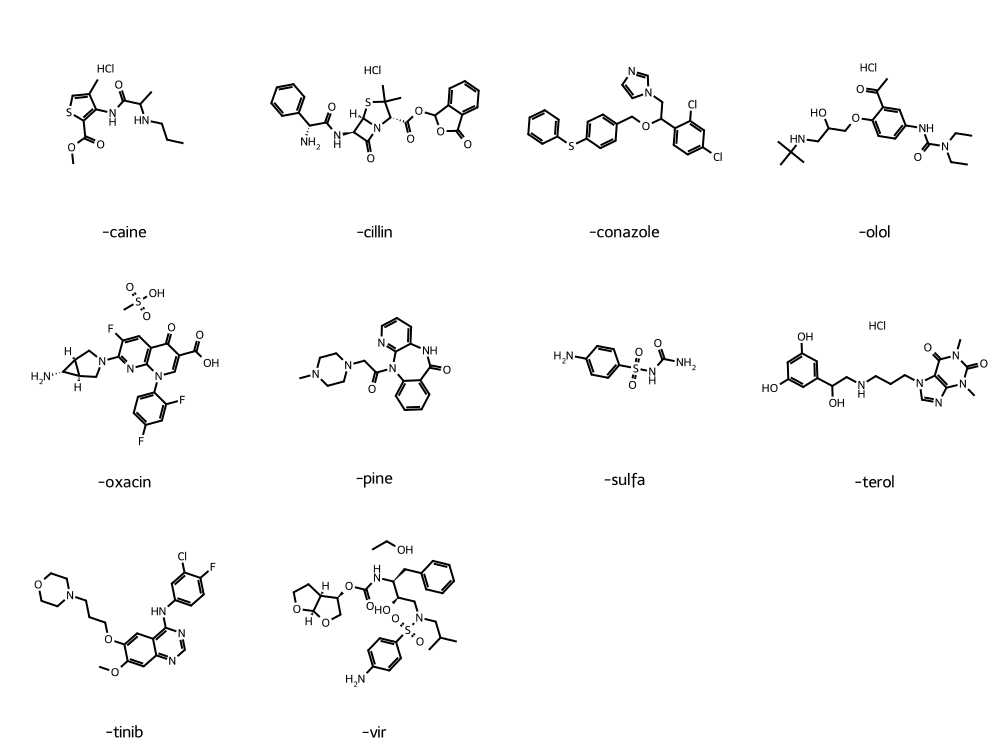

In [32]:
# Display the image
usan_example_img

In [33]:
# Save the image
save_molecule_image(usan_example_img, f"figures/{CHAPTER}/sampled_drugs.svg")

Image saved to figures/ch01/sampled_drugs.svg


In [34]:
sample_drugs

,Name,#RO5 Violations (Lipinski),Smiles,USAN Stem,ROMol,ECFP6
0,ARTICAINE HYDROCHLORIDE,0,CCCNC(C)C(=O)Nc1c(C)csc1C(=O)OC.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628ed50>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
0,TALAMPICILLIN HYDROCHLORIDE,0,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](N)c3ccccc3)C(=...,-cillin,<rdkit.Chem.rdchem.Mol object at 0x77429628dd20>,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
0,FENTICONAZOLE,1,Clc1ccc(C(Cn2ccnc2)OCc2ccc(Sc3ccccc3)cc2)c(Cl)c1,-conazole,<rdkit.Chem.rdchem.Mol object at 0x77429628fe60>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
0,CELIPROLOL HYDROCHLORIDE,0,CCN(CC)C(=O)Nc1ccc(OCC(O)CNC(C)(C)C)c(C(C)=O)c...,-olol,<rdkit.Chem.rdchem.Mol object at 0x774296290970>,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
0,TROVAFLOXACIN MESYLATE,0,CS(=O)(=O)O.N[C@@H]1[C@H]2CN(c3nc4c(cc3F)c(=O)...,-oxacin,<rdkit.Chem.rdchem.Mol object at 0x774296291a10>,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
0,PIRENZEPINE,0,CN1CCN(CC(=O)N2c3ccccc3C(=O)Nc3cccnc32)CC1,-pine,<rdkit.Chem.rdchem.Mol object at 0x774296292650>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
0,SULFACARBAMIDE,0,NC(=O)NS(=O)(=O)c1ccc(N)cc1,-sulfa,<rdkit.Chem.rdchem.Mol object at 0x774296292ff0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
0,REPROTEROL HYDROCHLORIDE,0,Cl.Cn1c(=O)c2c(ncn2CCCNCC(O)c2cc(O)cc(O)c2)n(C...,-terol,<rdkit.Chem.rdchem.Mol object at 0x774296293a00>,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
0,GEFITINIB,0,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,-tinib,<rdkit.Chem.rdchem.Mol object at 0x77429629c740>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
0,DARUNAVIR ETHANOLATE,1,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,-vir,<rdkit.Chem.rdchem.Mol object at 0x77429629e180>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


<h4 style="font-family:Georgia,'Iowan Old Style','Palatino Linotype',serif;font-weight:500;font-size:20px;line-height:1.12;margin:0 0 10px;letter-spacing:-.01em;"><b>Unsupervised Learning Example: PCA</b></h4>

In the drug discovery workflow, **chemical space exploration** is used to analyze and visualize safe, therapeutically effective compounds to understand the structural characteristics that drive specific drug behaviors. 

Molecular data is highly complex. For example, representing a molecule's structure can require a 1024-dimensional chemical feature space (such as a 1024-bit ECFP6 fingerprint vector), making it extremely difficult to interpret and visualize.

We'll use Principal Component Analysis (PCA) to reduce the dimensionality of our molecular fingerprints to 4 dimensions. This allows us to:
 
1. Visualize the chemical space of FDA-approved drugs
2. Identify patterns and clusters of similar drugs
3. Understand the distribution of different drug classes
 
PCA works by finding the directions (principal components) of maximum variance in the data.

In [42]:
def perform_pca_analysis(df, fingerprint_col='ECFP6', n_components=4):
    """
    Perform PCA on molecular fingerprints and add principal components to dataframe.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing molecular fingerprints
    fingerprint_col : str
        Column name containing fingerprints
    n_components : int
        Number of principal components to compute
        
    Returns:
    --------
    pandas.DataFrame
        Dataframe with added principal components
    sklearn.decomposition.PCA
        Fitted PCA model
    """
    print(f"Performing PCA with {n_components} components...")
    
    # Extract fingerprints as a numpy array
    X = np.array([x for x in df[fingerprint_col]])
    
    # Initialize and fit PCA model
    pca = PCA(n_components=n_components, random_state=42)
    pca_result = pca.fit_transform(X)
    
    # Add principal components to dataframe
    for i in range(n_components):
        df[f'PC{i+1}'] = pca_result.T[i]
    
    # Display explained variance
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    
    print("Explained variance ratio by component:")
    for i, var in enumerate(explained_variance):
        print(f"PC{i+1}: {var:.4f} ({cumulative_variance[i]:.4f} cumulative)")
    
    return df, pca

# Takeaway: PCA is unsupervised -- it compresses the 1024-bit fingerprints into a few
# axes of maximal variance so we can visualize this chemical space in 2-D.
# Perform PCA on our FDA approved drugs dataset
fda_approved_df, pca_model = perform_pca_analysis(fda_approved_df)

Performing PCA with 4 components...
Explained variance ratio by component:
PC1: 0.0642 (0.0642 cumulative)
PC2: 0.0431 (0.1073 cumulative)
PC3: 0.0345 (0.1418 cumulative)
PC4: 0.0293 (0.1711 cumulative)


Let's create visualizations to understand the PCA results. We'll use a pairplot to visualize the relationships between the first four principal components, colored by USAN stem.

In [43]:
fda_approved_df.head()

,Name,#RO5 Violations (Lipinski),Smiles,USAN Stem,ROMol,ECFP6,PC1,PC2,PC3,PC4
0,ARTICAINE HYDROCHLORIDE,0,CCCNC(C)C(=O)Nc1c(C)csc1C(=O)OC.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628ed50>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",-0.405866,-1.305908,-0.584966,0.120522
1,ETIDOCAINE HYDROCHLORIDE,0,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628eff0>,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.548748,-0.963631,-0.409488,0.630837
2,ROPIVACAINE HYDROCHLORIDE,0,CCCN1CCCC[C@H]1C(=O)Nc1c(C)cccc1C.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628eb20>,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.443182,-0.011319,-1.127333,0.646762
3,PROCAINE,0,CCN(CC)CCOC(=O)c1ccc(N)cc1,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628eb90>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",-0.868779,-0.761854,0.323953,1.854892
4,DIBUCAINE,0,CCCCOc1cc(C(=O)NCCN(CC)CC)c2ccccc2n1,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628ea40>,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, ...",-0.647600,-0.101296,0.290536,0.166428


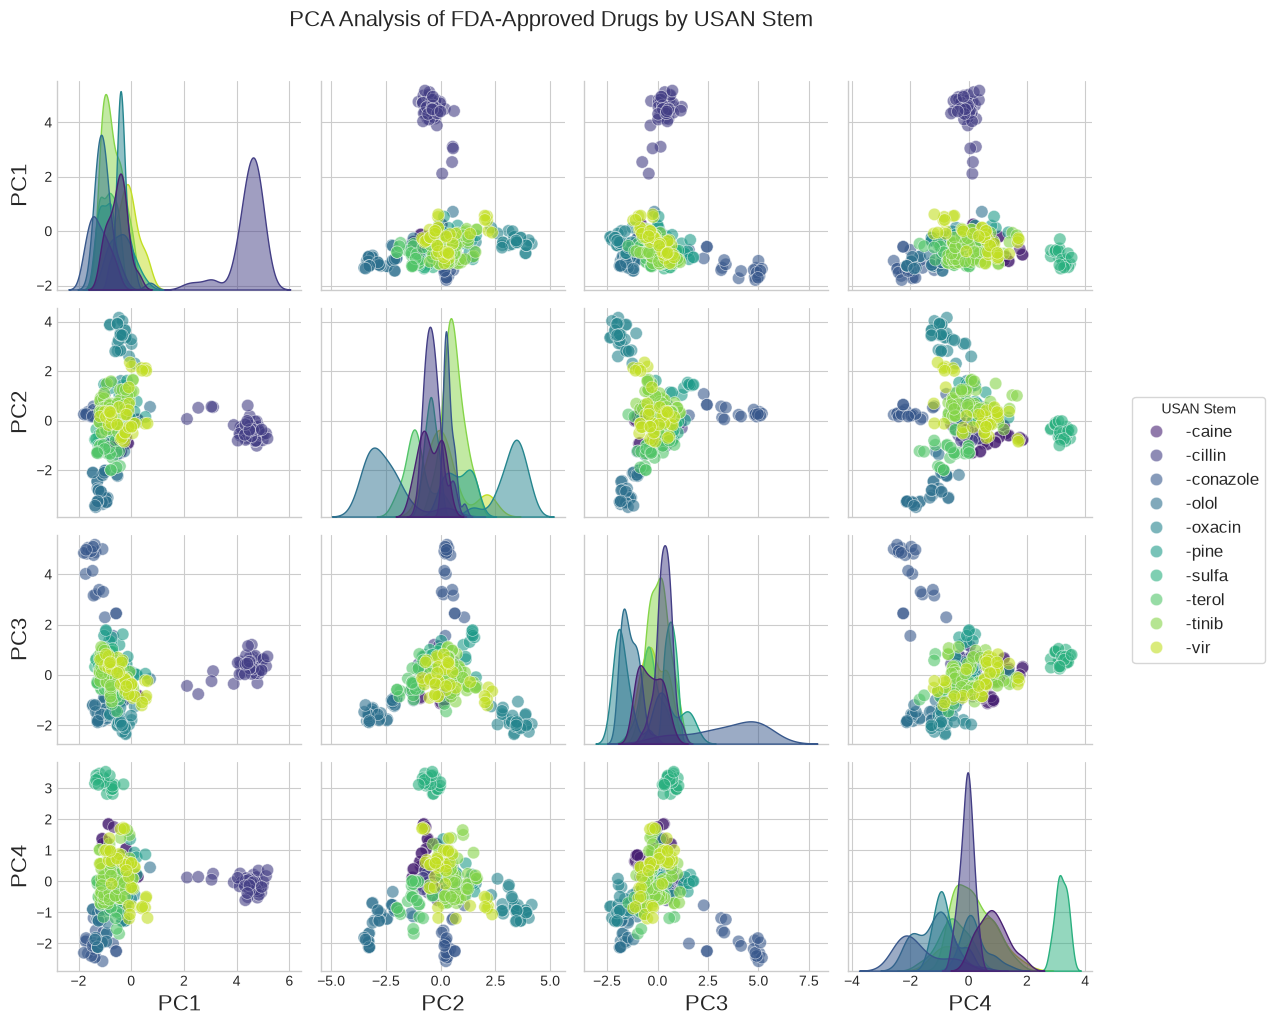

In [44]:
def plot_pca_results(df, group_col='USAN Stem', pc_cols=None):
    """
    Create visualizations of PCA results.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing PCA results
    group_col : str
        Column name for grouping/coloring
    pc_cols : list
        List of principal component columns to include
        
    Returns:
    --------
    matplotlib.figure.Figure
        Figure containing the visualization
    """
    if pc_cols is None:
        pc_cols = [f'PC{i+1}' for i in range(4)]
    
    # Create pairplot (seaborn builds and manages its own figure/grid)
    pairplot = sns.pairplot(
        df, 
        hue=group_col, 
        vars=pc_cols, 
        height=2.5,
        palette='viridis',
        diag_kind='kde',
        plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'w', 'linewidth': 0.5},
        diag_kws={'alpha': 0.5, 'fill': True}
    )
    
    # Add title
    pairplot.figure.suptitle('PCA Analysis of FDA-Approved Drugs by USAN Stem', 
                          y=1.02, fontsize=16)
    
    # Improve legend
    handles = pairplot._legend_data.values()
    labels = pairplot._legend_data.keys()
    
    pairplot._legend.remove()
    pairplot.figure.legend(handles=handles, labels=labels, 
                       loc='center right', bbox_to_anchor=(1.15, 0.5),
                       frameon=True, fontsize=12, title='USAN Stem')
    
    pairplot.figure.tight_layout()
    return pairplot.figure

# Create and display PCA visualization
pca_fig = plot_pca_results(fda_approved_df)

As seen in figure above, we see that certain drugs occupy their own regions in space. Notably, drugs with USAN stem designations of “-caine”, “-cillin”, “-pine”, and “-sulfa” occupy their own distinct chemical subspace for at least one of the PC cross sections. Other drug classes, such as drugs with “-vir” USAN stem designation, are hard to visually differentiate from the other drugs. We can train a ML model to understand the boundaries that separate the USAN stem classes from each other within the chemical feature space better.

In [16]:
# Sanity check: PCA added the four principal-component columns we requested.
assert {'PC1', 'PC2', 'PC3', 'PC4'}.issubset(fda_approved_df.columns), "PCA columns missing"

# Preview the frame with its new principal-component columns.
preview_df(fda_approved_df, "FDA drugs + principal components")

FDA drugs + principal components: 343 rows x 10 cols
  columns: ['Name', '#RO5 Violations (Lipinski)', 'Smiles', 'USAN Stem', 'ROMol', 'ECFP6', 'PC1', 'PC2', 'PC3', 'PC4']


,Name,#RO5 Violations (Lipinski),Smiles,USAN Stem,ROMol,ECFP6,PC1,PC2,PC3,PC4
0,ARTICAINE HYDROCHLORIDE,0,CCCNC(C)C(=O)Nc1c(C)csc1C(=O)OC.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x7982a6973a70>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",-0.405866,-1.305908,-0.584966,0.120522
1,ETIDOCAINE HYDROCHLORIDE,0,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x7982a6973ae0>,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.548748,-0.963631,-0.409488,0.630837
2,ROPIVACAINE HYDROCHLORIDE,0,CCCN1CCCC[C@H]1C(=O)Nc1c(C)cccc1C.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x7982a6973990>,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.443182,-0.011319,-1.127333,0.646762


In [45]:
# Save the visualization (use the returned Figure object, not global pyplot state).
pca_fig.savefig(f'figures/{CHAPTER}/pca_pairplot.png', bbox_inches='tight', dpi=600)
pca_fig.savefig(f'figures/{CHAPTER}/pca_pairplot.svg', bbox_inches='tight', dpi=600)

#### **Supervised Learning Example: Logistic Regression**

Now let's apply a supervised learning approach to see if we can classify drugs based on their USAN stems using their principal components. We'll:
 
1. Create binary target variables for two USAN stems: '-cillin' (antibiotics) and '-olol' (beta blockers)
2. Train logistic regression models to predict these drug classes
3. Visualize the decision boundaries

In [46]:
def prepare_classification_targets(df, stems_to_classify):
    """
    Create binary target variables for specific USAN stems.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing USAN stem information
    stems_to_classify : list
        List of USAN stems to create target variables for
        
    Returns:
    --------
    pandas.DataFrame
        Dataframe with added binary target variables
    """
    for stem in stems_to_classify:
        stem_col = stem.replace('-', '')  # Create valid column name
        df[stem_col] = (df['USAN Stem'] == stem).astype(int)
        print(f"Created target variable '{stem_col}' with {df[stem_col].sum()} positive examples")
    
    return df

# Define USAN stems for classification
stems_to_classify = ['-cillin', '-olol']

# Create binary target variables
fda_approved_df = prepare_classification_targets(fda_approved_df, stems_to_classify)

Created target variable 'cillin' with 46 positive examples
Created target variable 'olol' with 37 positive examples


In [48]:
fda_approved_df.head()

,Name,#RO5 Violations (Lipinski),Smiles,USAN Stem,ROMol,ECFP6,PC1,PC2,PC3,PC4,cillin,olol
0,ARTICAINE HYDROCHLORIDE,0,CCCNC(C)C(=O)Nc1c(C)csc1C(=O)OC.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628ed50>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",-0.405866,-1.305908,-0.584966,0.120522,0,0
1,ETIDOCAINE HYDROCHLORIDE,0,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628eff0>,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.548748,-0.963631,-0.409488,0.630837,0,0
2,ROPIVACAINE HYDROCHLORIDE,0,CCCN1CCCC[C@H]1C(=O)Nc1c(C)cccc1C.Cl,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628eb20>,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-0.443182,-0.011319,-1.127333,0.646762,0,0
3,PROCAINE,0,CCN(CC)CCOC(=O)c1ccc(N)cc1,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628eb90>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",-0.868779,-0.761854,0.323953,1.854892,0,0
4,DIBUCAINE,0,CCCCOc1cc(C(=O)NCCN(CC)CC)c2ccccc2n1,-caine,<rdkit.Chem.rdchem.Mol object at 0x77429628ea40>,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, ...",-0.647600,-0.101296,0.290536,0.166428,0,0


In [49]:
def train_and_visualize_classifier(df, target_col, feature_cols, title):
    """
    Train a logistic regression classifier and visualize its decision boundary.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing features and target
    target_col : str
        Column name for the target variable
    feature_cols : list
        List of feature column names (should be exactly 2 for visualization)
    title : str
        Title for the plot
        
    Returns:
    --------
    sklearn.linear_model.LogisticRegression
        Trained classifier
    matplotlib.figure.Figure
        Figure containing the visualization
    """
    if len(feature_cols) != 2:
        raise ValueError("Exactly 2 feature columns required for visualization")
    
    # Extract features and target
    X = df[feature_cols].values
    y = df[target_col].values
    
    # Train logistic regression model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X, y)
    
    # Create a meshgrid for visualization
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    
    # Calculate predictions on the meshgrid
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot decision boundary
    contour = ax.contourf(xx, yy, Z, 25, cmap='Blues', alpha=0.7, vmin=0, vmax=1)
    ax_c = fig.colorbar(contour)
    ax_c.set_label(f"Probability of {target_col}")
    ax_c.set_ticks([0, .25, .5, .75, 1])
    
    # Plot data points
    scatter = ax.scatter(
        X[:, 0], X[:, 1], 
        c=y, s=100, cmap='Blues', 
        vmin=-0.2, vmax=1.2,
        edgecolor='black', linewidth=1.5
    )
    
    # Add labels and title
    ax.set(
        aspect='equal',
        xlabel=feature_cols[0], 
        ylabel=feature_cols[1],
        title=title
    )
    
    fig.tight_layout()
    return model, fig

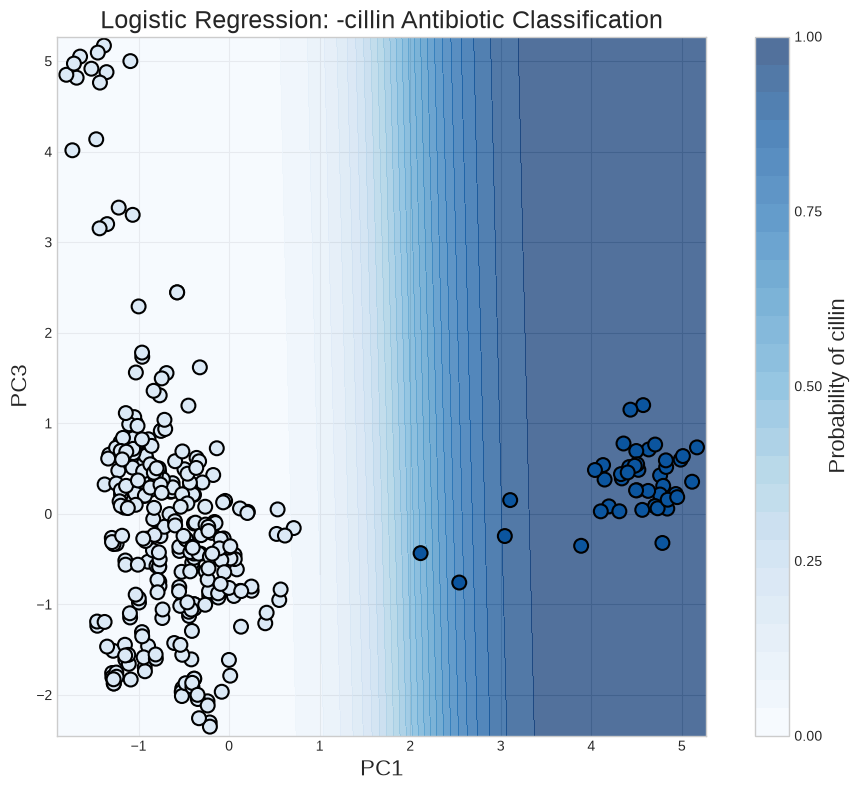

In [54]:
# Takeaway: logistic regression is supervised -- given labels (is this a -cillin?) it
# learns a decision boundary in PCA space separating that drug class from the rest.
# Train and visualize model for -cillin classification
cillin_model, cillin_fig = train_and_visualize_classifier(
    df=fda_approved_df,
    target_col='cillin',
    feature_cols=['PC1', 'PC3'],
    title='Logistic Regression: -cillin Antibiotic Classification'
)

# Save the visualization
cillin_fig.savefig(f'figures/{CHAPTER}/cillin_decision_boundary.png', bbox_inches='tight', dpi=600)
cillin_fig.savefig(f'figures/{CHAPTER}/cillin_decision_boundary.svg', bbox_inches='tight', dpi=600)

In [52]:
# Calculate and display accuracy
cillin_acc = cillin_model.score(
    fda_approved_df[['PC1', 'PC3']], 
    fda_approved_df['cillin']
)
print(f"Accuracy for -cillin classification: {cillin_acc:.4f}")

Accuracy for -cillin classification: 1.0000


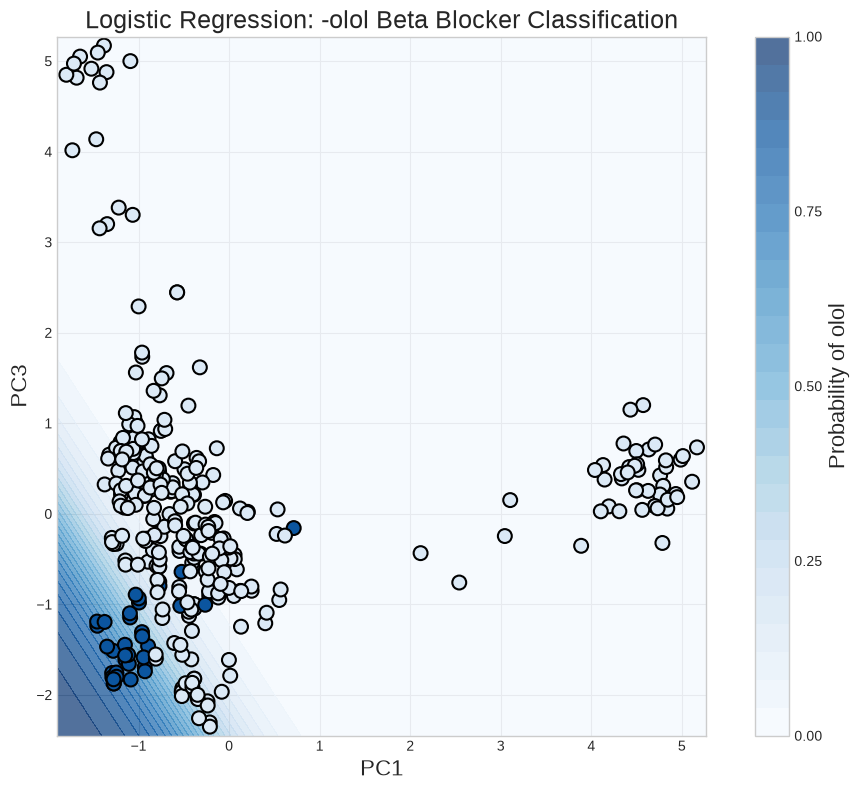

In [55]:
# Train and visualize model for -olol classification
olol_model, olol_fig = train_and_visualize_classifier(
    df=fda_approved_df,
    target_col='olol',
    feature_cols=['PC1', 'PC3'],
    title='Logistic Regression: -olol Beta Blocker Classification'
)

# Save the visualization
olol_fig.savefig(f'figures/{CHAPTER}/olol_decision_boundary.png', bbox_inches='tight', dpi=600)
olol_fig.savefig(f'figures/{CHAPTER}/olol_decision_boundary.svg', bbox_inches='tight', dpi=600)

In [56]:
# Calculate and display accuracy
olol_acc = olol_model.score(
    fda_approved_df[['PC1', 'PC3']], 
    fda_approved_df['olol']
)
print(f"Accuracy for -olol classification: {olol_acc:.4f}")

Accuracy for -olol classification: 0.9563


<div style="margin:0 0 16px;padding:12px 18px;border-left:2px solid #A20025;background:#FDF3F5;">
<strong style="font-family:ui-monospace,'SF Mono','JetBrains Mono',Menlo,monospace;font-size:10.5px;letter-spacing:.16em;text-transform:uppercase;color:#A20025;">Key result</strong><br>
<span style="color:#3d3436;font-size:14.5px;">A fingerprint turns a molecule into a fixed-length vector, and once molecules are vectors the ordinary machine-learning toolkit applies unchanged. Nothing in the <code>PCA</code> or <code>LogisticRegression</code> calls above is chemistry-specific; the chemistry all lives in how the vector was built.</span>
</div>

---

## **1.3 Deep Learning's Value Proposition**

---

## **1.4 Introducing Drug Discovery**

**Figure 1.2 (Eroom's Law) is generated by the code below; the rest of this section is narrative in the book.**

*This section in the book covers the overall drug discovery process, including:*
 
- Target identification and validation
- Hit identification
- Lead optimization
- Preclinical development
- Clinical trials
- Regulatory approval
 
*The examples above demonstrate computational methods that support various stages in this process.*

A central motivation for applying machine learning to drug discovery is **Eroom's Law** (Moore's Law
spelled backwards): the number of new drugs approved per inflation-adjusted \$ billion of
pharmaceutical R&D fell steeply and steadily for six decades
([Scannell et al., 2012](https://doi.org/10.1038/nrd3681)). In the data plotted below the metric
falls about 66-fold between 1950 and 2010, halving roughly every 9.9 years. After 2010 the decline
stops: the series flattens and by 2025 sits about 3.9 times above where the old trend line would
have put it, the break reported by
[Ringel et al., 2020](https://doi.org/10.1038/d41573-020-00059-3).

*How to read it.* Both panels share a year axis and both use logarithmic vertical scales, so a
constant exponential rate appears as a straight line. The upper panel is the efficiency metric
itself: grey circles are single years, the heavy crimson line is a five-year centred mean, the black
dashed line is a least-squares fit to 1950 through 2010 continued past 2010 as a dotted
counterfactual, and the blue dashed line is the same regression run on 2011 through 2025. The lower
panel decomposes the ratio, re-indexing spending and approvals to 1950 = 1, and shows that this is
mostly a denominator story: real R&D grew about 160-fold while output grew about 2.5-fold.

*Data and provenance: `data/ch01/eroom_law.csv` (see `data/ch01/eroom_law_SOURCES.md`). The
numerator is FDA new drug approvals, from the FDA History Office for 1950 through 1992 and CDER's
Novel Drug Approvals thereafter. The denominator is PhRMA Annual Membership Survey R&D deflated by
the BLS CPI-U to constant 2024 dollars. The survey reports directly only from 1983, so the pre-1970
denominator is reconstructed from a documented anchor: that stretch is drawn dashed and carries a
sensitivity band. The ratio is computed from the two source series rather than fitted to the
published trend.*

In [24]:
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

# The CSV names the two sensitivity series after the 1950 anchor each assumes. The
# plotting code below just wants a low and a high bound on the reconstructed years.
eroom = pd.read_csv(f"data/{CHAPTER}/eroom_law.csv").rename(columns={
    "sens_approvals_per_busd_rd_anchor35m": "approvals_per_busd_rd_lo",
    "sens_approvals_per_busd_rd_anchor85m": "approvals_per_busd_rd_hi",
})


def loglinear_fit(years, values):
    """Least-squares fit of log10(values) on year. Returns (slope, intercept, r2)."""
    obs = np.log10(values)
    slope, intercept = np.polyfit(years, obs, 1)
    pred = intercept + slope * years
    r2 = 1 - ((obs - pred) ** 2).sum() / ((obs - obs.mean()) ** 2).sum()
    return slope, intercept, r2


# The classic Eroom's Law window. On a log scale a constant exponential decay is a
# straight line, so the fitted slope converts directly into a halving time.
old = eroom[(eroom.year >= 1950) & (eroom.year <= 2010)]
b, a, r2 = loglinear_fit(old.year, old.approvals_per_busd_rd)
halving = -np.log10(2) / b
fold60 = 10 ** (-b * 60)

# The same fit against the smoothed series, which is the line the figure draws.
smoothed = old.dropna(subset=["approvals_per_busd_rd_5yr"])
_, _, r2_5 = loglinear_fit(smoothed.year, smoothed.approvals_per_busd_rd_5yr)

# The post-2010 break: its own fit, plus how far recent years sit above the old trend.
recent_era = eroom[eroom.year >= 2011]
b2, a2, _ = loglinear_fit(recent_era.year, recent_era.approvals_per_busd_rd)
recent = eroom[eroom.year >= 2018]
gap = (recent.approvals_per_busd_rd / 10 ** (a + b * recent.year)).mean()

# How much the halving time depends on the reconstructed pre-1970 denominator: refit
# with the low and high anchors substituted in for the years that were reconstructed.
halvings = []
for bound in ("lo", "hi"):
    series = eroom[f"approvals_per_busd_rd_{bound}"].where(
        eroom.year <= 1969, eroom.approvals_per_busd_rd)
    window = eroom.year <= 2010
    slope, _ = np.polyfit(eroom.year[window], np.log10(series[window]), 1)
    halvings.append(-np.log10(2) / slope)
h_lo, h_hi = sorted(halvings)

fits = {"a": a, "b": b, "a2": a2, "b2": b2, "halving": halving, "gap": gap}

print(f"1950-2010: {fold60:.0f}x fall, halving every {halving:.1f} years "
      f"({h_lo:.1f}-{h_hi:.1f} across the anchor sensitivity)")
print(f"           R2 = {r2:.3f} on annual values, {r2_5:.3f} on the 5-year mean")
print(f"2011-2025: {gap:.1f}x above the extrapolated pre-2010 trend")

1950-2010: 66x fall, halving every 9.9 years (9.3-11.0 across the anchor sensitivity)
           R2 = 0.904 on annual values, 0.947 on the 5-year mean
2011-2025: 3.9x above the extrapolated pre-2010 trend


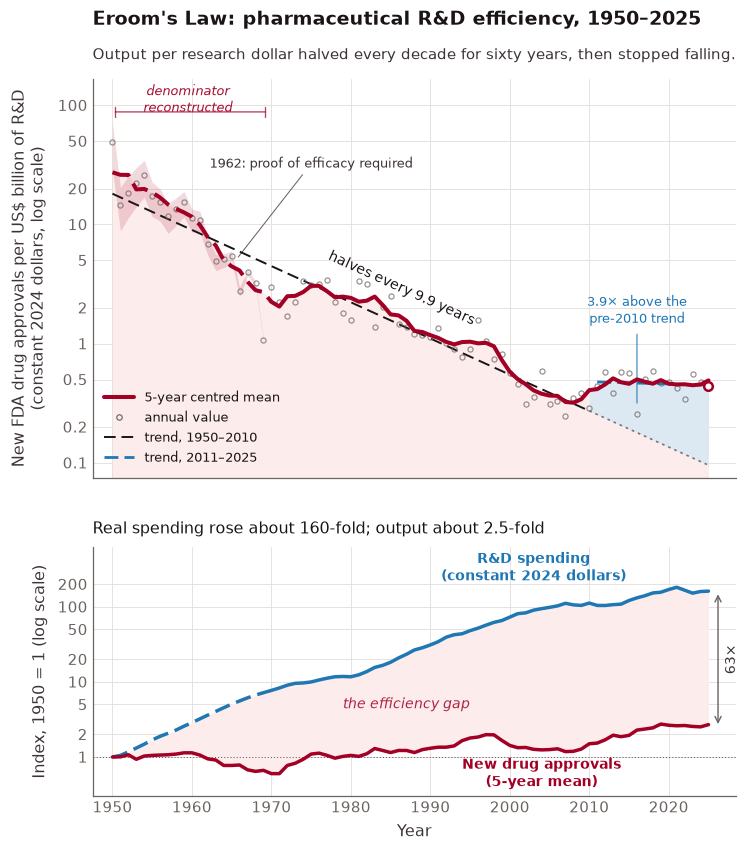

In [25]:
# This figure carries its own typography. `mpl.rc_context` scopes those settings to
# the figure so the rest of the chapter keeps the style set in the setup section.
EROOM_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.labelsize": 11.4,
    "axes.titlesize": 12,
    "xtick.labelsize": 10.6,
    "ytick.labelsize": 10.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#6B6461",
    "axes.linewidth": 0.9,
    "text.color": "#1A1416",
    "axes.labelcolor": "#3d3436",
    "xtick.color": "#6B6461",
    "ytick.color": "#6B6461",
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",  # keeps SVG text selectable rather than outlined
}

CRIMSON = "#A20025"   # the focal series
BLUSH = "#FDECEC"     # fills under it
BLUE = "#1f77b4"      # the R&D denominator
INK = "#1A1416"
BODY = "#3d3436"
MUTED = "#6B6461"
HAIR = "#E7E2DF"
BLUEPALE = "#DCE9F3"


def plot_eroom_law(eroom, fits):
    """Plot Eroom's Law as two stacked log-scale panels and return the Figure.

    Panel A is the efficiency metric itself: annual values, a five-year centred mean
    (dashed before 1970, where the R&D denominator is reconstructed rather than
    reported), the fitted 1950-2010 trend continued past 2010 as a counterfactual,
    and the separate 2011-2025 trend. Panel B decomposes the ratio into its two
    parts, both re-indexed to 1950 = 1.
    """
    a, b, a2, b2 = fits["a"], fits["b"], fits["a2"], fits["b2"]
    halving, gap = fits["halving"], fits["gap"]

    fig = plt.figure(figsize=(7.6, 8.7))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.60, 1.0], left=0.128, right=0.975,
                          top=0.902, bottom=0.078, hspace=0.215)
    axA = fig.add_subplot(gs[0])
    axB = fig.add_subplot(gs[1], sharex=axA)

    X0, X1 = 1947.5, 2028.5
    yr = eroom.year.values

    for ax in (axA, axB):
        ax.grid(True, which="major", axis="y", color=HAIR, lw=0.7, zorder=0)
        ax.grid(True, which="major", axis="x", color=HAIR, lw=0.7, zorder=0)
        ax.set_axisbelow(True)

    # --- Panel A: the efficiency metric ------------------------------------
    axA.set_yscale("log")
    axA.set_xlim(X0, X1)
    axA.set_ylim(0.075, 165)

    roll = eroom.approvals_per_busd_rd_5yr.values
    axA.fill_between(yr, 0.075, roll, color=BLUSH, zorder=1, lw=0)

    # Uncertainty on the reconstructed pre-1970 denominator.
    pre = eroom.year <= 1969
    axA.fill_between(eroom.year[pre], eroom.approvals_per_busd_rd_lo[pre],
                     eroom.approvals_per_busd_rd_hi[pre],
                     color=CRIMSON, alpha=0.15, lw=0, zorder=2)

    # The 1950-2010 trend, then extrapolated forward as a counterfactual.
    xf = np.arange(1950, 2011)
    axA.plot(xf, 10 ** (a + b * xf), ls=(0, (6, 3)), color=INK, lw=1.4, zorder=5)
    xc = np.arange(2010, 2026)
    axA.plot(xc, 10 ** (a + b * xc), ls=(0, (1.6, 2.4)), color=INK, lw=1.2,
             alpha=0.55, zorder=5)

    # Raw annual values.
    axA.plot(yr, eroom.approvals_per_busd_rd, ls="none", marker="o", ms=3.7,
             mfc="none", mec=MUTED, mew=0.85, alpha=0.72, zorder=6)

    # The smoothed series, dashed where the denominator is reconstructed.
    m70 = yr <= 1970
    axA.plot(yr[m70], roll[m70], color=CRIMSON, lw=2.9, ls=(0, (4.5, 2.0)),
             solid_capstyle="round", zorder=8)
    axA.plot(yr[~m70 | (yr == 1970)], roll[~m70 | (yr == 1970)], color=CRIMSON,
             lw=2.9, solid_capstyle="round", zorder=8)

    # Post-2010 direction.
    xp = np.arange(2011, 2026)
    axA.plot(xp, 10 ** (a2 + b2 * xp), color=BLUE, lw=2.0, ls=(0, (5, 2.2)), zorder=7)

    # The provisional 2025 denominator.
    last = eroom[eroom.year == 2025].iloc[0]
    axA.plot([2025], [last.approvals_per_busd_rd], marker="o", ms=6.2, mfc="white",
             mec=CRIMSON, mew=1.8, zorder=9)

    axA.set_ylabel("New FDA drug approvals per US$ billion of R&D\n"
                   "(constant 2024 dollars, log scale)", labelpad=7)
    axA.yaxis.set_major_locator(
        FixedLocator([0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]))
    axA.yaxis.set_major_formatter(FuncFormatter(
        lambda v, _: f"{v:g}" if v >= 1 else f"{v:.1f}"))
    axA.yaxis.set_minor_formatter(NullFormatter())

    # Title and subtitle are sized to fit the canvas in DejaVu Sans, the fallback
    # when TeX Gyre Heros is not installed (which is the usual case on Colab).
    hdr = dict(xy=(0, 1), xycoords="axes fraction", textcoords="offset points",
               ha="left", va="bottom", annotation_clip=False)
    axA.annotate("Eroom's Law: pharmaceutical R&D efficiency, 1950–2025",
                 xytext=(0, 36), fontsize=14.0, color=INK, fontweight="bold", **hdr)
    axA.annotate("Output per research dollar halved every decade for sixty years, "
                 "then stopped falling.",
                 xytext=(0, 12), fontsize=10.6, color=BODY, **hdr)

    ann = dict(fontsize=9.6, color=BODY, ha="center",
               arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.75,
                               shrinkA=1, shrinkB=3))
    axA.annotate("1962: proof of efficacy required",
                 xy=(1965.5, 5.0), xytext=(1975.0, 30.0), **ann)

    # The wedge between what the old trend implied and what actually happened.
    mw = yr >= 2010
    cf = 10 ** (a + b * yr[mw])
    axA.fill_between(yr[mw], cf, roll[mw], where=roll[mw] > cf, color=BLUEPALE,
                     lw=0, zorder=3)
    axA.annotate(f"{gap:.1f}× above the\npre-2010 trend",
                 xy=(2016.0, 0.30), xytext=(2016.0, 1.9), fontsize=9.6,
                 color=BLUE, ha="center", va="center",
                 arrowprops=dict(arrowstyle="-", color=BLUE, lw=0.75,
                                 shrinkA=3, shrinkB=2))

    axA.text(1959.5, 112, "denominator\nreconstructed", fontsize=9.0, color=CRIMSON,
             ha="center", va="center", alpha=0.95, style="italic")
    axA.annotate("", xy=(1950, 88), xytext=(1969.6, 88),
                 arrowprops=dict(arrowstyle="|-|,widthA=0.32,widthB=0.32",
                                 color=CRIMSON, lw=0.95, alpha=0.75))

    # Set the halving-time label at the on-screen angle of the trend line, which
    # needs a first draw so the data-to-display transform is settled.
    fig.canvas.draw()
    p = axA.transData.transform(np.column_stack(
        [[1970, 1990], 10 ** (a + b * np.array([1970, 1990]))]))
    angle = np.degrees(np.arctan2(p[1, 1] - p[0, 1], p[1, 0] - p[0, 0]))
    axA.text(1986.0, 2.55, f"halves every {halving:.1f} years", fontsize=10.4,
             color=INK, rotation=angle, rotation_mode="anchor", ha="center",
             va="bottom")

    legend_entries = [
        Line2D([], [], color=CRIMSON, lw=2.9, label="5-year centred mean"),
        Line2D([], [], ls="none", marker="o", ms=3.9, mfc="none", mec=MUTED,
               mew=0.85, label="annual value"),
        Line2D([], [], color=INK, ls=(0, (6, 3)), lw=1.4,
               label="trend, 1950–2010"),
        Line2D([], [], color=BLUE, ls=(0, (5, 2.2)), lw=2.0,
               label="trend, 2011–2025"),
    ]
    axA.legend(handles=legend_entries, loc="lower left", frameon=False, fontsize=9.6,
               handlelength=2.2, labelspacing=0.44, borderpad=0.1,
               bbox_to_anchor=(0.006, 0.012))

    # --- Panel B: spending against output ----------------------------------
    axB.set_yscale("log")
    axB.set_ylim(0.30, 620)
    axB.set_xlim(X0, X1)

    rd_i = eroom.rd_real_index_1950.values
    ap_i = eroom.approvals_index_1950.values

    axB.fill_between(yr, ap_i, rd_i, color=BLUSH, lw=0, zorder=1)
    axB.plot(yr[m70], rd_i[m70], color=BLUE, lw=2.5, ls=(0, (4.5, 2.0)), zorder=4)
    axB.plot(yr[~m70 | (yr == 1970)], rd_i[~m70 | (yr == 1970)], color=BLUE,
             lw=2.5, zorder=4)
    axB.plot(yr, ap_i, color=CRIMSON, lw=2.5, zorder=5)
    axB.axhline(1.0, color=MUTED, lw=0.7, ls=(0, (1.2, 2.0)), zorder=3)

    rd_end = eroom[eroom.year == 2024].rd_real_index_1950.iloc[0]
    ap_end = eroom[eroom.year == 2024].approvals_index_1950.iloc[0]

    axB.text(2003.0, 330, "R&D spending\n(constant 2024 dollars)", fontsize=10.4,
             color=BLUE, ha="center", va="center", fontweight="bold")
    axB.text(2004.0, 0.60, "New drug approvals\n(5-year mean)", fontsize=10.4,
             color=CRIMSON, ha="center", va="center", fontweight="bold")
    axB.text(1987.0, 5.0, "the efficiency gap", fontsize=10.4, color=CRIMSON,
             ha="center", va="center", style="italic", alpha=0.85)

    axB.annotate("", xy=(2026.2, rd_end), xytext=(2026.2, ap_end),
                 arrowprops=dict(arrowstyle="<->", color=MUTED, lw=1.0))
    axB.text(2027.0, np.sqrt(rd_end * ap_end), f"{rd_end / ap_end:.0f}×",
             fontsize=10.0, color=BODY, ha="left", va="center", rotation=90)

    axB.set_ylabel("Index, 1950 = 1 (log scale)", labelpad=7)
    axB.set_xlabel("Year", labelpad=6)
    axB.yaxis.set_major_locator(FixedLocator([1, 2, 5, 10, 20, 50, 100, 200]))
    axB.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    axB.yaxis.set_minor_formatter(NullFormatter())
    axB.set_title(f"Real spending rose about {rd_end:.0f}-fold; "
                  f"output about {ap_end:.1f}-fold",
                  loc="left", pad=10, fontsize=11.8, color=INK)

    for ax in (axA, axB):
        ax.xaxis.set_major_locator(FixedLocator(np.arange(1950, 2026, 10)))
        ax.xaxis.set_minor_locator(FixedLocator(np.arange(1950, 2026, 5)))
    plt.setp(axA.get_xticklabels(), visible=False)
    axA.tick_params(axis="x", length=0)

    return fig


with mpl.rc_context(EROOM_RC):
    eroom_fig = plot_eroom_law(eroom, fits)
    # No `bbox_inches="tight"` here: the gridspec margins above are hand-tuned and
    # a tight bounding box would override them.
    eroom_fig.savefig(f"figures/{CHAPTER}/eroom_law.png", dpi=400, facecolor="white")
    eroom_fig.savefig(f"figures/{CHAPTER}/eroom_law.svg", facecolor="white")
plt.show()

<div style="font-size:12.5px;color:#6B6461;margin:6px 0 14px;">Figure 1.2. Eroom's Law. Top: new FDA drug approvals per US$ billion of R&amp;D in constant 2024 dollars, falling about 66-fold from 1950 to 2010 and then flattening. Bottom: the same two series indexed to 1950 = 1, showing that real spending rose about 160-fold while output rose about 2.5-fold.</div>

<hr style="border:0;border-top:1px solid #A20025;opacity:.55;margin:34px 0 12px;">
<h2 style="font-family:Georgia,'Iowan Old Style','Palatino Linotype',serif;font-weight:500;font-size:23px;margin:0 0 10px;color:#1A1416;">Summary</h2>

 Developing therapeutics entails a long, arduous process. Traditional development from ideation to market is costly (magnitude of billions of dollars), lengthy (10 to 15 years), and risky (attrition of over 90%). Through advances in AI, we can discover cures that have better safety profiles, address medical conditions or diseases with low coverage, and can reach patients quicker.

 Drug discovery can be thought of as a difficult search problem that exists at the intersection of the chemical search space of 10^63 medicinal compounds and the biological search space of 10^5 targets.

 We can represent molecules computationally using SMILES, a text-based notation that encodes molecular structure as a character string, or as molecular graphs, where atoms are nodes and bonds are edges. These representations serve as input data for machine learning models.

 ML is a subfield of AI that enables computers to learn from and make decisions based on data, automatically and without explicit programming or rules on how to behave. Example ML algorithms include logistic regression and random forests. Deep learning is a subfield of ML that uses deep neural networks to extract complex patterns and representations from data.

 Applications of AI to drug design include molecule property prediction for virtual screening, creation of compound libraries with de novo molecule generation, synthesis pathway prediction, and protein folding simulation.

 We can segment the early drug discovery pipeline into four main phases: target identification, hit discovery, hit-to-lead or lead identification, and lead optimization. Target identification designates a valid target whose activity is worth modulating to address some disease or disorder. Hit discovery uncovers chemical compounds with activity against the target. Lead identification selects the most promising hits and lead optimization improves their potency, selectivity, and ADMET properties to be suitable for preclinical study.

 Popular, well-maintained chemical data repositories include ChEMBL, ChEBI, PubChem, Protein Data Bank (PDB), AlphaFoldDB, and ZINC. When using a new data source, learn how it was assembled and how quality is maintained. Garbage data in, garbage model out. See “Appendix B: Chemical Data Repositories” for more information.

<hr style="border:0;border-top:1px solid #A20025;opacity:.55;margin:34px 0 12px;">
<h2 style="font-family:Georgia,'Iowan Old Style','Palatino Linotype',serif;font-weight:500;font-size:23px;margin:0 0 10px;color:#1A1416;">Interactive Exploration</h2>

<details style="margin:0 0 14px;border-top:1px solid #E7E2DF;border-bottom:1px solid #E7E2DF;">
<summary style="cursor:pointer;padding:11px 0;font-family:ui-monospace,'SF Mono','JetBrains Mono',Menlo,monospace;font-size:12px;letter-spacing:.05em;text-transform:uppercase;color:#A20025;">Try it yourself &middot; 4 ideas</summary>
<div style="padding:4px 0 14px;font-size:14.5px;color:#3d3436;">
<p>As you progress through the book, and as we cover additional concepts, consider returning back to this notebook and experimenting with the code above by:</p>
<ol>
<li>Choosing different USAN stems to analyze</li>
<li>Using different molecular fingerprints (e.g., MACCS keys, topological fingerprints)</li>
<li>Training models with different principal components</li>
<li>Exploring other molecular descriptors available in RDKit</li>
</ol>
<p><em>See the book for more exercises.</em></p>
</div>
</details>

<hr style="border:0;border-top:1px solid #A20025;opacity:.55;margin:34px 0 12px;">
<h2 style="font-family:Georgia,'Iowan Old Style','Palatino Linotype',serif;font-weight:500;font-size:23px;margin:0 0 10px;color:#1A1416;">References and Further Reading</h2>

<ol style="font-size:13.5px;color:#6B6461;padding-left:20px;">
<li style="margin:7px 0;">RDKit Documentation. <a href="https://www.rdkit.org/docs/">rdkit.org/docs</a></li>
<li style="margin:7px 0;">The FDA's Approved Drug Products. <a href="https://www.accessdata.fda.gov/scripts/cder/daf/">accessdata.fda.gov/scripts/cder/daf</a></li>
<li style="margin:7px 0;">Lipinski, C. A. et al. (1997). <em>Experimental and computational approaches to estimate solubility and permeability in drug discovery and development settings.</em> Adv. Drug Deliv. Rev. 23, 3-25.</li>
<li style="margin:7px 0;">Appendix B of this book, <em>Chemical Data Repositories</em>, for ideas on data sources and best practices for using them in your own projects.</li>
</ol>